# Phase 2 — Feature Engineering
## Credit Risk Scoring Model

Feature engineering is the process of transforming raw data into a form that a machine learning model can learn from effectively.

**Raw data problems we need to fix:**
1. Categorical columns are string codes — models only understand numbers
2. Numerical columns have very different scales — unfair to the model
3. `credit_amount` and `duration` are right-skewed — distorts distance-based calculations
4. 70/30 class imbalance — model will be biased toward predicting "Good"
5. We can create new features that carry more signal than existing ones

This notebook solves all of the above.

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Imports successful.")

Imports successful.


## Step 2 — Load Data

We load `german_named.csv` — the output from Phase 1. It has proper column names and is otherwise untouched.

In [2]:
df = pd.read_csv('../data/processed/german_named.csv')
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Loaded: 1000 rows × 21 columns


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1


## Step 3 — Recode Target to Binary (0/1)

Right now: `1 = Good`, `2 = Bad`.  
We recode to: `0 = Good`, `1 = Bad`.

**Why?**
- Standard ML convention: `1` means the "positive" class — the thing we're trying to detect (default/bad credit)
- Scikit-learn, SHAP, and most evaluation tools assume `1` is the class of interest
- Probability outputs (e.g. `predict_proba`) will then mean: *probability of being a bad borrower*

In [3]:
# 1 (Good) → 0,  2 (Bad) → 1
df['target'] = df['target'].map({1: 0, 2: 1})

print("Target recoded:")
print(df['target'].value_counts().rename({0: 'Good (0)', 1: 'Bad (1)'}))

Target recoded:
target
Good (0)    700
Bad (1)     300
Name: count, dtype: int64


## Step 4 — Ordinal Encoding for Ordered Categoricals

Some categorical columns have a **natural order**. For example:
- `checking_status`: No Account → <0 DM → 0–200 DM → >=200 DM (increasing wealth)
- `savings_status`: Unknown/None → <100 DM → ... → >=1000 DM
- `employment`: Unemployed → <1yr → 1–4yr → 4–7yr → >=7yr
- `job`: Unskilled non-resident → Unskilled resident → Skilled → Management

For these, we use **ordinal encoding** — assign integers that preserve the order.

**Why not one-hot for these?**  
One-hot would say `<1yr` and `>=7yr` are completely unrelated categories.  
Ordinal encoding tells the model: more years employed = lower number = different risk profile. The model can learn from the ordering.

In [4]:
ordinal_maps = {
    # Ordered low → high balance (more money = lower risk)
    'checking_status': {'A11': 0, 'A12': 1, 'A13': 2, 'A14': 3},

    # Ordered low → high savings
    'savings_status': {'A65': 0, 'A61': 1, 'A62': 2, 'A63': 3, 'A64': 4},

    # Ordered unemployed → long-tenured
    'employment': {'A71': 0, 'A72': 1, 'A73': 2, 'A74': 3, 'A75': 4},

    # Ordered low-skill → high-skill
    'job': {'A171': 0, 'A172': 1, 'A173': 2, 'A174': 3},
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)
    print(f"{col}: {df[col].unique()}")

print("\nOrdinal encoding done.")

checking_status: [0 1 3 2]
savings_status: [0 1 3 4 2]
employment: [4 2 3 0 1]
job: [2 1 3 0]

Ordinal encoding done.


## Step 5 — One-Hot Encoding for Nominal Categoricals

Nominal = no natural order. Examples:
- `purpose`: car vs education vs business — none is "more" than the other
- `housing`: rent vs own vs free — no inherent order
- `credit_history`: categories describe behaviors, not a ranked scale

For these we use **one-hot encoding** — create a new binary column for each category.

**Example:**  
`purpose = A43 (Radio/TV)` becomes:
```
purpose_A40  purpose_A41  purpose_A42  purpose_A43  ...
    0             0             0            1       ...
```

**Why `drop_first=True`?**  
If you have 3 categories and 2 binary columns, the third is always implied (if both are 0, it must be the third). Keeping all 3 creates **multicollinearity** — a redundancy that confuses Logistic Regression. Dropping the first category avoids this.

In [5]:
nominal_cols = [
    'credit_history', 'purpose', 'personal_status',
    'other_parties', 'property_magnitude', 'other_payment_plans',
    'housing', 'own_telephone', 'foreign_worker'
]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df.shape}")
print(f"New columns added: {df.shape[1] - 21}")  # 21 was original column count
df.head(2)

Shape after one-hot encoding: (1000, 39)
New columns added: 18


,checking_status,duration,credit_amount,savings_status,employment,installment_commitment,residence_since,age,existing_credits,job,...,other_parties_A103,property_magnitude_A122,property_magnitude_A123,property_magnitude_A124,other_payment_plans_A142,other_payment_plans_A143,housing_A152,housing_A153,own_telephone_A192,foreign_worker_A202
0,0,6,1169,0,4,4,4,67,2,2,...,False,False,False,False,False,True,True,False,True,False
1,1,48,5951,1,2,2,2,22,1,2,...,False,False,False,False,False,True,True,False,False,False


## Step 6 — Create New Features

We can engineer new features that combine existing ones to create stronger signals.

**Features to create:**

| New Feature | Formula | Why |
|---|---|---|
| `monthly_rate` | `credit_amount / duration` | Monthly repayment burden — high burden = higher risk |
| `age_employment_ratio` | `age / (employment + 1)` | How much of their life have they been employed? |
| `credit_to_age_ratio` | `credit_amount / age` | Loan size relative to life stage |

These are called **interaction features** — they capture relationships between two variables that the model might not discover on its own.

In [6]:
df['monthly_rate']          = df['credit_amount'] / df['duration']
df['age_employment_ratio']  = df['age'] / (df['employment'] + 1)
df['credit_to_age_ratio']   = df['credit_amount'] / df['age']

print("New features created:")
print(df[['monthly_rate', 'age_employment_ratio', 'credit_to_age_ratio']].describe().T[['mean','min','max']])

New features created:
                            mean        min          max
monthly_rate          167.687020  24.055556  2482.666667
age_employment_ratio   12.465417   4.000000    75.000000
credit_to_age_ratio    99.495822   6.097561   745.380952


## Step 7 — Log Transform Skewed Features

From EDA we saw `credit_amount` and `duration` are right-skewed — a long tail of large values.

**Why does skew hurt models?**
- Logistic Regression assumes features have a roughly linear relationship with the log-odds of the target
- A heavily skewed feature violates this — the model struggles to learn from it
- Log transform compresses the long tail, making the distribution more symmetric

**Why `log1p` and not `log`?**  
`log(0)` is undefined (−∞). `log1p(x)` = `log(x + 1)`, which safely handles zero values.

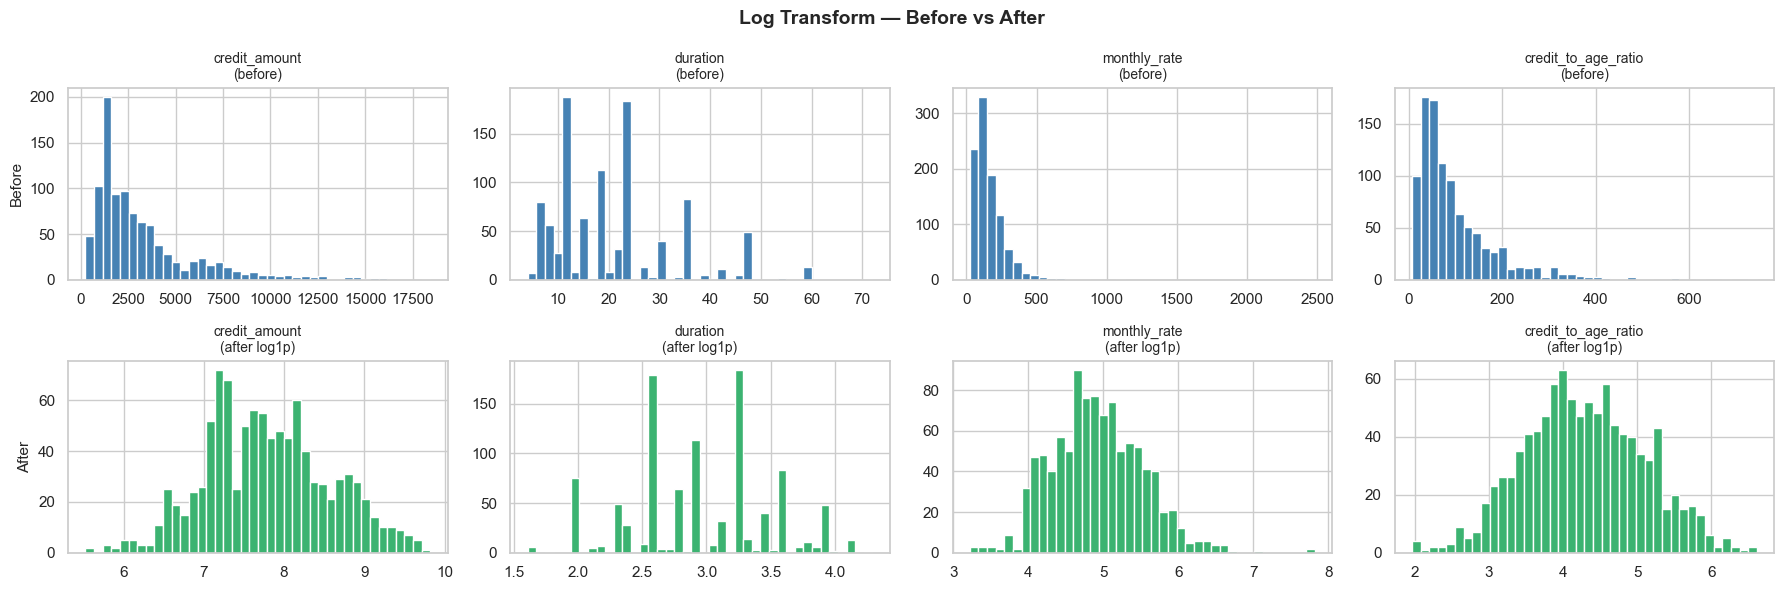

Log transform applied to: ['credit_amount', 'duration', 'monthly_rate', 'credit_to_age_ratio']


In [7]:
skewed_cols = ['credit_amount', 'duration', 'monthly_rate', 'credit_to_age_ratio']

fig, axes = plt.subplots(2, len(skewed_cols), figsize=(18, 6))

for i, col in enumerate(skewed_cols):
    # Before
    axes[0][i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[0][i].set_title(f'{col}\n(before)', fontsize=10)

    # Apply transform
    df[col] = np.log1p(df[col])

    # After
    axes[1][i].hist(df[col], bins=40, color='mediumseagreen', edgecolor='white')
    axes[1][i].set_title(f'{col}\n(after log1p)', fontsize=10)

axes[0][0].set_ylabel('Before', fontsize=11)
axes[1][0].set_ylabel('After', fontsize=11)

plt.suptitle('Log Transform — Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

print("Log transform applied to:", skewed_cols)

## Step 8 — Train / Test Split (BEFORE Scaling and SMOTE)

We split the data into train (80%) and test (20%) **before** doing any scaling or SMOTE.

**This order is critical. Here's why:**

### The Data Leakage Problem
If you scale the full dataset first, then split:
- The scaler sees test data while computing mean/std
- Test data "leaks" information into the training process
- Your model appears to perform better than it actually would on truly unseen data

### The SMOTE Leakage Problem
If you apply SMOTE before splitting:
- Synthetic samples of test rows end up in the training set
- The model has essentially "seen" the test set
- Evaluation metrics are completely meaningless

**Correct order:**  
`Split → Scale train only → Apply SMOTE to train only → Train model → Evaluate on raw test`

In [8]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,       # Reproducibility — same split every time
    stratify=y             # Maintain 70/30 ratio in both train and test
)

print(f"Train size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")
print(f"\nTrain class balance:\n{y_train.value_counts().rename({0:'Good', 1:'Bad'})}")
print(f"\nTest class balance:\n{y_test.value_counts().rename({0:'Good', 1:'Bad'})}")

Train size : 800 rows
Test size  : 200 rows

Train class balance:
target
Good    560
Bad     240
Name: count, dtype: int64

Test class balance:
target
Good    140
Bad      60
Name: count, dtype: int64


## Step 9 — Feature Scaling (StandardScaler)

We scale all numerical features so they have **mean = 0** and **standard deviation = 1**.

**Why scale?**
- Logistic Regression uses gradient descent — features on large scales dominate the weight updates
- Without scaling: `credit_amount` (range: 100s–10000s) drowns out `num_dependents` (range: 1–2)
- With scaling: every feature contributes proportionally based on its actual predictive power

**Why only `fit` on train, then `transform` both?**
- `fit` computes the mean and std from the training data
- `transform` applies that same mean/std to both train and test
- If we `fit` on test too, we'd use test statistics to normalize — data leakage again

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# Convert back to DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print("Scaling done.")
print(f"\nBefore scaling — credit_amount mean: {X_train['credit_amount'].mean():.2f}, std: {X_train['credit_amount'].std():.2f}")
print(f"After scaling  — credit_amount mean: {X_train_scaled['credit_amount'].mean():.2f}, std: {X_train_scaled['credit_amount'].std():.2f}")

Scaling done.

Before scaling — credit_amount mean: 7.77, std: 0.77
After scaling  — credit_amount mean: 0.00, std: 1.00


## Step 10 — SMOTE (Fix Class Imbalance)

Our training set has ~560 Good vs ~240 Bad. SMOTE creates **synthetic** Bad Credit samples to balance this.

**How SMOTE works:**
1. For each minority sample (Bad Credit), find its k-nearest neighbours (also Bad Credit)
2. Pick a random neighbour
3. Create a new synthetic point somewhere along the line between them
4. Repeat until classes are balanced

**Why not just duplicate existing Bad samples?**  
Simple duplication (oversampling) makes the model memorize specific bad borrowers.  
SMOTE creates new, slightly different samples — the model learns the general pattern, not specific cases.

**Why not just undersample Good samples?**  
We'd throw away 320 real data points. With only 1,000 rows, we can't afford to lose data.

**SMOTE only on training data — never test.**  
The test set must reflect real-world distribution to give honest evaluation.

Before SMOTE:
  Good (0): 560  |  Bad (1): 240

After SMOTE:
  Good (0): 560  |  Bad (1): 560

Total training samples: 1120


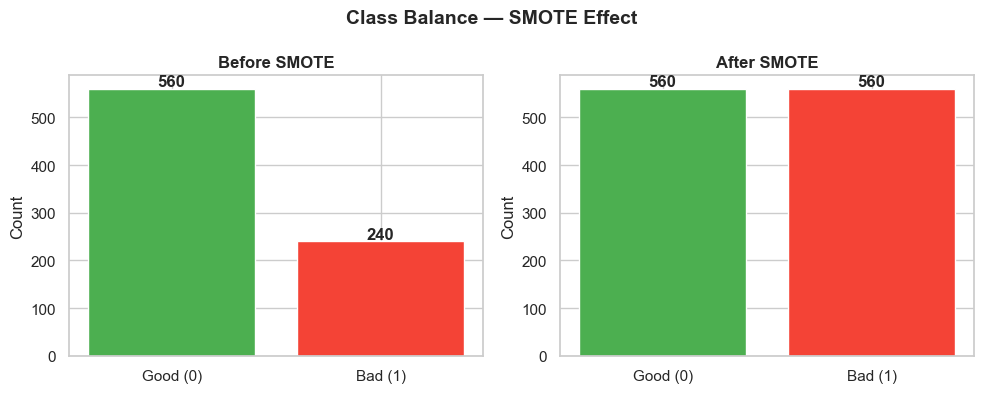

In [10]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Good (0): {(y_train == 0).sum()}  |  Bad (1): {(y_train == 1).sum()}")
print(f"\nAfter SMOTE:")
print(f"  Good (0): {(y_train_sm == 0).sum()}  |  Bad (1): {(y_train_sm == 1).sum()}")
print(f"\nTotal training samples: {len(y_train_sm)}")

# Visualise the balance change
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (labels, title) in zip(axes, [
    ([y_train.value_counts()[0], y_train.value_counts()[1]], 'Before SMOTE'),
    ([(y_train_sm==0).sum(), (y_train_sm==1).sum()], 'After SMOTE'),
]):
    ax.bar(['Good (0)', 'Bad (1)'], labels, color=['#4CAF50', '#F44336'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(labels):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Balance — SMOTE Effect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Save Processed Data

We save four files:
- `X_train_processed.csv` / `X_test_processed.csv` — feature matrices
- `y_train_processed.csv` / `y_test_processed.csv` — labels

The train set includes SMOTE-balanced data. The test set is raw (no SMOTE).  
We also save the scaler so the Streamlit app can use it for real-time predictions.

In [11]:
import pickle

# Save feature matrices
pd.DataFrame(X_train_sm, columns=X_train.columns).to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv', index=False)

# Save labels
pd.Series(y_train_sm, name='target').to_csv('../data/processed/y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv('../data/processed/y_test.csv', index=False)

# Save scaler for use in Streamlit app
with open('../data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Saved:")
print(f"  X_train.csv  — {X_train_sm.shape[0]} rows × {X_train_sm.shape[1]} cols  (SMOTE balanced)")
print(f"  X_test.csv   — {X_test_scaled.shape[0]} rows × {X_test_scaled.shape[1]} cols")
print(f"  y_train.csv  — {len(y_train_sm)} labels")
print(f"  y_test.csv   — {len(y_test)} labels")
print(f"  scaler.pkl   — StandardScaler fitted on training data")
print("\nFeature Engineering complete. Ready for Phase 3 — Modeling.")

Saved:
  X_train.csv  — 1120 rows × 41 cols  (SMOTE balanced)
  X_test.csv   — 200 rows × 41 cols
  y_train.csv  — 1120 labels
  y_test.csv   — 200 labels
  scaler.pkl   — StandardScaler fitted on training data

Feature Engineering complete. Ready for Phase 3 — Modeling.
